### Esym(ρ) from neutron-star observables with deep neural networks — new data set
Training notebook for the new data, based on the training notebook of the paper (`MR_EOS_v2.ipynb`, not included here):

- EOSs from `eos_v3_cli.x --paper` (J0 = Jsym = 0; L and Ksym sampled as in the paper), 4 runs of 100K tries: `eos_paper_v1–v4.h5`
- NS sequences from `tov_ml_cli.x` (tovSolve, pseudo-enthalpy formalism): `ns_paper_v1–v4.h5`

Two DNNs, as in the paper: input **M–R** or **M–Λ** (50 random masses in 1–2 M$_\odot$ with R or Λ at those masses), output **E$_{sym}$(ρ)** at 100 densities in 0.07–0.8 fm$^{-3}$ (up to 5ρ$_0$).

Same network and settings as in the paper (12 dense layers of 100, Adam/AMSgrad, learning rate 0.003, MSE loss, batch size 500, at most 2000 epochs), with these changes:

- **early stopping** on the validation loss (patience 100 epochs, best weights restored)
- split: **40,000** sequences for training, the rest divided equally into validation and test
- the input scaler is fitted on the **training set only**
- seeded random numbers (reproducible); the data preparation is in `esym_data.py`

The training itself is in `train_esym_dnn.py` (`python train_esym_dnn.py --input MR` / `--input MLambda`), which saves the models in `models/`. With `RUN_TRAINING = True` this notebook trains the models itself with the same code; otherwise it loads the saved results.

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')
os.environ.setdefault('TF_FORCE_GPU_ALLOW_GROWTH', 'true')

import esym_data as ed

# --- Settings ---
INPUTS       = ['MR', 'MLambda']   # DNN inputs
RUN_TRAINING = False               # True: train here (same code as train_esym_dnn.py)
MODEL_DIR    = 'models'
N_TRAIN      = 40000
PATIENCE     = 100
MAX_EPOCHS   = 2000
SEED         = 42
LABEL        = {'MR': 'M-R', 'MLambda': r'M-$\Lambda$'}

rho0 = ed.rho0
rhox = ed.RHOX
ed.rc_params()

### Data

In [2]:
data = ed.load_dataset(ed.NS_FILES)
print('NS files:', ', '.join(ed.NS_FILES))
print('Sequences: %d, pass the quality filter: %d (%.1f%%)' % (data['n_total'], data['n_kept'], 100*data['n_kept']/data['n_total']))
print('L: %.1f - %.1f MeV,  Ksym: %.1f - %.1f MeV' % (data['L'].min(), data['L'].max(), data['Ksym'].min(), data['Ksym'].max()))
idx_train, idx_val, idx_test = ed.split_indices(data['n_kept'], N_TRAIN, SEED)
print('Training: %d, validation: %d, test: %d' % (len(idx_train), len(idx_val), len(idx_test)))

NS files: ns_paper_v1.h5, ns_paper_v2.h5, ns_paper_v3.h5, ns_paper_v4.h5
Sequences: 60144, pass the quality filter: 49357 (82.1%)
L: 49.6 - 86.8 MeV,  Ksym: -63.2 - 100.0 MeV
Training: 40000, validation: 4678, test: 4679


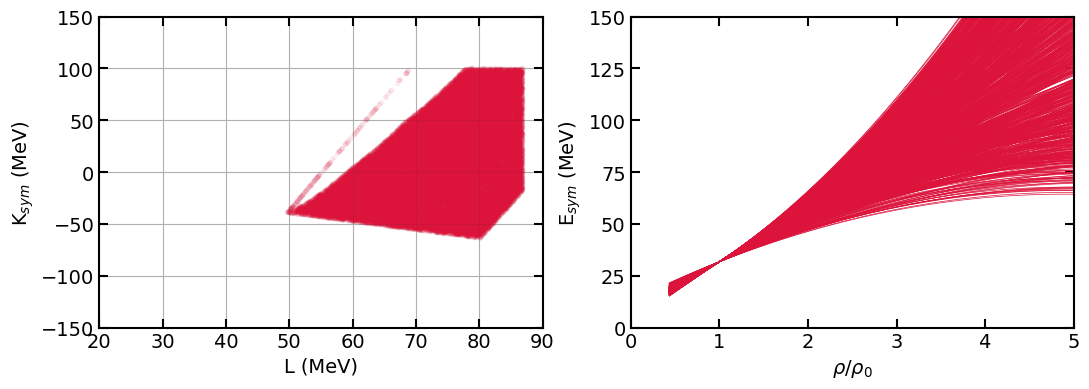

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.0))
ax[0].plot(data['L'], data['Ksym'], 'o', color='crimson', alpha=0.05, ms=3)
ax[0].set_xlim(20, 90); ax[0].set_ylim(-150, 150); ax[0].grid()
ax[0].set_xlabel('L (MeV)', size=14); ax[0].set_ylabel(r'K$_{sym}$ (MeV)', size=14)
for i in range(1000):
    ax[1].plot(rhox/rho0, ed.e_sym(rhox, data['L'][i], data['Ksym'][i]), color='crimson', lw=0.5)
ax[1].set_xlim(0, 5); ax[1].set_ylim(0, 150)
ax[1].set_xlabel(r'$\rho/\rho_0$', size=14); ax[1].set_ylabel(r'E$_{sym}$ (MeV)', size=14)
plt.tight_layout(); plt.show()

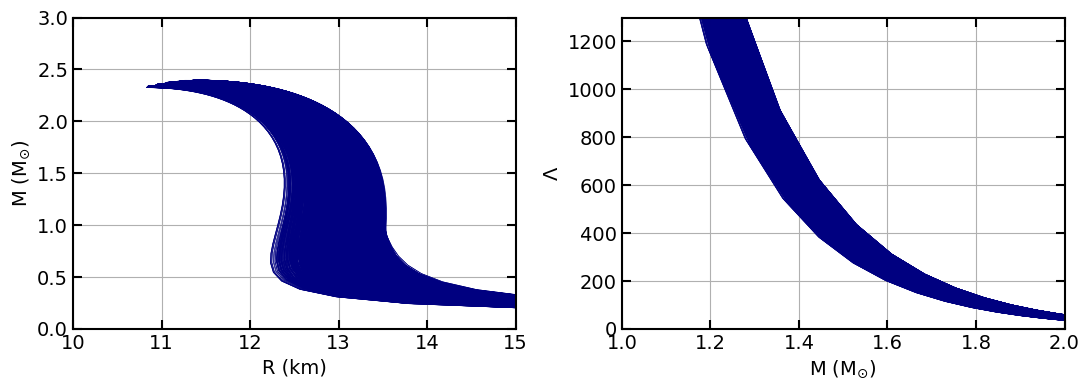

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.0))
for i in range(3000):
    k = np.argmax(data['m'][i])
    ax[0].plot(data['r'][i, :k+1], data['m'][i, :k+1], color='navy', lw=0.5)
    ax[1].plot(data['m'][i, :k+1], data['Lambda'][i, :k+1], color='navy', lw=0.5)
ax[0].set_xlim(10, 15); ax[0].set_ylim(0, 3); ax[0].set_xlabel('R (km)', size=14); ax[0].set_ylabel(r'M (M$_{\odot}$)', size=14)
ax[1].set_xlim(1, 2); ax[1].set_ylim(0, 1300); ax[1].set_xlabel(r'M (M$_{\odot}$)', size=14); ax[1].set_ylabel(r'$\Lambda$', size=14)
ax[0].grid(); ax[1].grid(); plt.tight_layout(); plt.show()

### Training
Early stopping monitors the validation loss: training stops when it has not improved for `PATIENCE` epochs, and the weights of the best epoch are restored. With `RUN_TRAINING = False` the results saved by `train_esym_dnn.py` are used.

In [5]:
if RUN_TRAINING:
    from train_esym_dnn import train
    for kind in INPUTS:
        train(kind, ed.NS_FILES, N_TRAIN, MAX_EPOCHS, PATIENCE, 500, 0.003, SEED, MODEL_DIR)

metrics = {k: json.load(open(os.path.join(MODEL_DIR, 'esym_%s_metrics.json' % k))) for k in INPUTS}
history = {k: pd.read_csv(os.path.join(MODEL_DIR, 'esym_%s_history.csv' % k)) for k in INPUTS}
for k in INPUTS:
    m = metrics[k]
    print('%-8s epochs run: %4d, best epoch: %4d, best val_loss: %.4g, training time: %.0f s'
          % (k, m['epochs_run'], m['best_epoch'], m['best_val_loss'], m['train_time_s']))

MR       epochs run: 2000, best epoch: 1991, best val_loss: 0.02005, training time: 2439 s
MLambda  epochs run: 2000, best epoch: 1995, best val_loss: 0.06718, training time: 2490 s


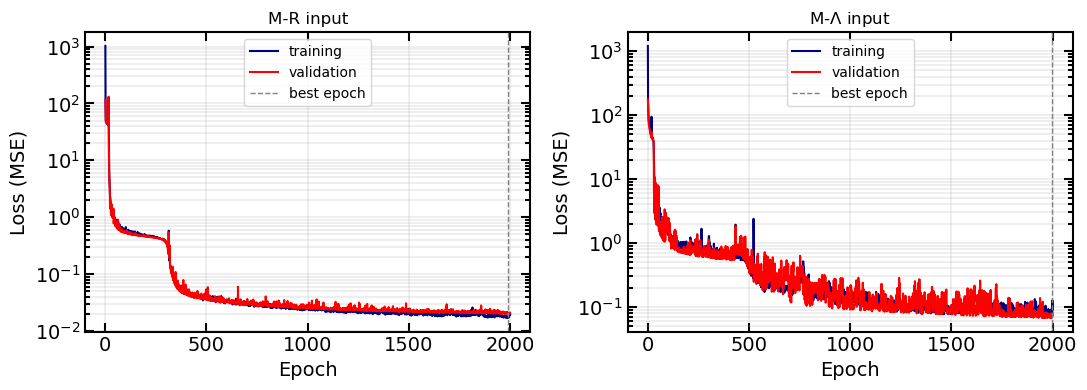

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.0))
for a, k in zip(ax, INPUTS):
    h = history[k]; e = h['epoch'] + 1
    a.plot(e, h['loss'], color='navy', label='training')
    a.plot(e, h['val_loss'], color='red', label='validation')
    a.axvline(metrics[k]['best_epoch'], color='grey', ls='--', lw=1, label='best epoch')
    a.set_yscale('log'); a.set_xlabel('Epoch', size=14); a.set_ylabel('Loss (MSE)', size=14)
    a.set_title(LABEL[k] + ' input'); a.legend(); a.grid(which='both', lw=0.3)
plt.tight_layout(); plt.show()

### Test set

In [7]:
from tensorflow import keras

models, tests = {}, {}
for k in INPUTS:
    models[k] = keras.models.load_model(os.path.join(MODEL_DIR, 'esym_%s.keras' % k))
    tests[k] = dict(np.load(os.path.join(MODEL_DIR, 'esym_%s_test.npz' % k)))
    pred = models[k].predict(tests[k]['x_test'].astype('float32'), batch_size=500, verbose=0)
    print('%-8s predictions of the loaded model equal the saved ones: %s' % (k, np.allclose(pred, tests[k]['pred'], atol=1e-4)))
    tests[k]['pred'] = pred
models['MR'].summary()

2026-09-30 20:12:17.548301: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-30 20:12:17.560522: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-30 20:12:17.564561: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


MR       predictions of the loaded model equal the saved ones: True


MLambda  predictions of the loaded model equal the saved ones: True


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 100)            │        10,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 484,802 (1.85 MB)

 Trainable params: 121,200 (473.44 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 363,602 (1.39 MB)

In [8]:
print('Absolute error of Esym on the test set (MeV):')
print('%-8s %24s %12s' % ('input', 'at 5 rho0 (mean +- std)', 'all rho'))
for k in INPUTS:
    err = np.abs(tests[k]['y_test'] - tests[k]['pred'])
    print('%-8s %10.2f +- %4.2f (n=%d) %10.2f'
          % (k, err[:, -1].mean(), err[:, -1].std(), len(err), err.mean()))

Absolute error of Esym on the test set (MeV):
input     at 5 rho0 (mean +- std)      all rho
MR             0.18 +- 0.16 (n=4679)       0.07
MLambda        0.47 +- 0.44 (n=4679)       0.16


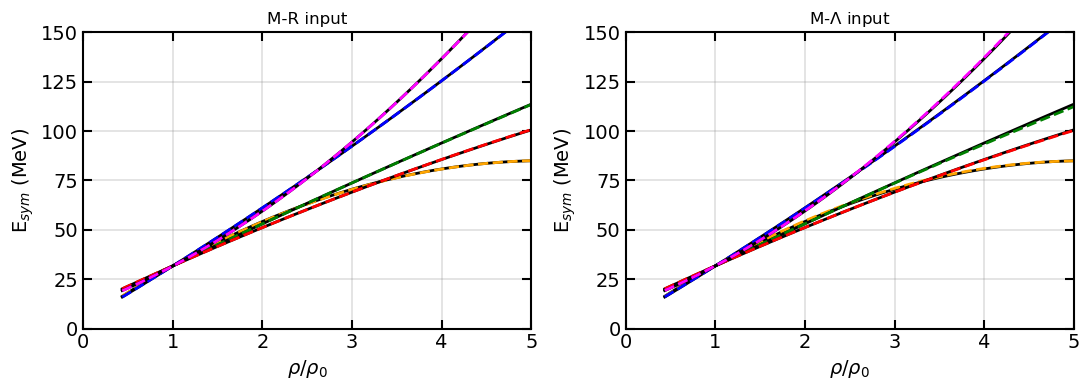

In [9]:
cols = ['orange', 'green', 'blue', 'red', 'magenta']
samples = [10, 20, 100, 583, 797]
fig, ax = plt.subplots(1, 2, figsize=(11, 4.0))
for a, k in zip(ax, INPUTS):
    t = tests[k]
    for i, cc in zip(samples, cols):
        a.plot(rhox/rho0, t['y_test'][i], color='black', lw=2)
        a.plot(rhox/rho0, t['pred'][i], '--', color=cc, lw=2)
    a.set_xlim(0, 5); a.set_ylim(0, 150); a.set_title(LABEL[k] + ' input')
    a.set_xlabel(r'$\rho/\rho_0$', size=14); a.set_ylabel(r'E$_{sym}$ (MeV)', size=14)
    a.grid(lw=0.3, color='grey')
plt.tight_layout(); plt.show()

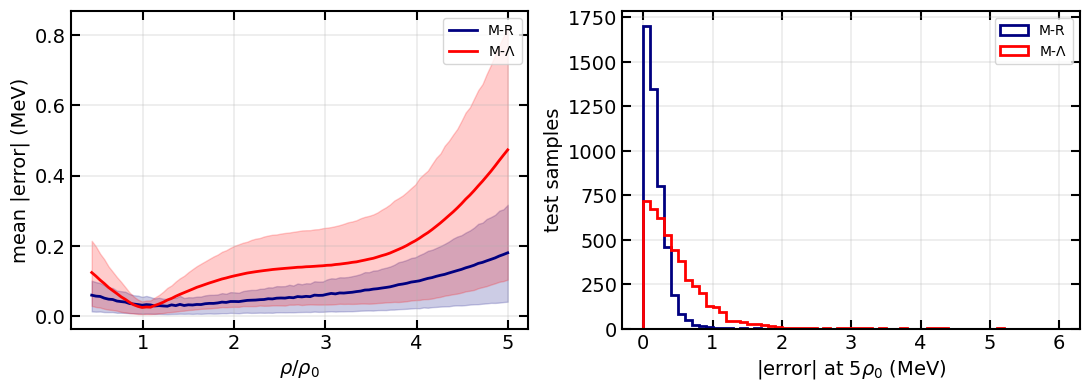

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.0))
for k, cc in zip(INPUTS, ['navy', 'red']):
    err = np.abs(tests[k]['y_test'] - tests[k]['pred'])
    ax[0].plot(rhox/rho0, err.mean(axis=0), color=cc, lw=2, label=LABEL[k])
    ax[0].fill_between(rhox/rho0, np.percentile(err, 16, axis=0), np.percentile(err, 84, axis=0), color=cc, alpha=0.2)
    ax[1].hist(err[:, -1], bins=60, range=(0, 6), histtype='step', color=cc, lw=2, label=LABEL[k])
ax[0].set_xlabel(r'$\rho/\rho_0$', size=14); ax[0].set_ylabel('mean |error| (MeV)', size=14); ax[0].legend(); ax[0].grid(lw=0.3)
ax[1].set_xlabel(r'|error| at 5$\rho_0$ (MeV)', size=14); ax[1].set_ylabel('test samples', size=14); ax[1].legend(); ax[1].grid(lw=0.3)
plt.tight_layout(); plt.show()

### Files
- `models/esym_<input>.keras`, `models/esym_<input>.weights.h5`: trained models (best epoch)
- `models/esym_<input>_scaler.npz`: input scaler (`esym_data.Scaler.load`)
- `models/esym_<input>_test.npz`: test set (raw and scaled inputs, outputs, predictions, EOS parameters)
- `models/esym_<input>_history.csv`, `models/esym_<input>_metrics.json`: loss history, test errors and settings

The figures of the paper for this data are made by `figures_v2.ipynb`.